In [2]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import mediapipe as mp

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

import pickle

from tensorflow.keras import layers, models, callbacks

# DATA PREPARATION

In [5]:
FINAL_DATA_PATH = "../dataset/csv/ds_cctv_v1.csv"
df = pd.read_csv(FINAL_DATA_PATH)
df

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,y74,z74,v74,x75,y75,z75,v75,face_d15,face_s15,hand_s15
0,Nutup Muka,0.469739,0.578589,-0.127777,0.993265,0.440848,0.569411,-0.112306,0.994901,0.439771,...,0.711073,-0.029289,0.473242,0.495799,0.711073,-0.029289,0.473242,0.0,1.0,1.0
1,Nutup Muka,0.445407,0.614889,0.017926,0.995142,0.429321,0.619205,-0.039531,0.995156,0.433832,...,0.570589,0.175774,0.242573,0.472730,0.570589,0.175774,0.242573,0.0,0.0,0.0
2,Nutup Muka,0.445444,0.615121,-0.014786,0.997897,0.430551,0.620001,-0.072877,0.998852,0.432003,...,0.573695,0.211646,0.227217,0.469184,0.573695,0.211646,0.227217,0.0,0.0,0.0
3,Nutup Muka,0.445540,0.614011,-0.004351,0.998440,0.430781,0.619389,-0.064572,0.999206,0.432518,...,0.512440,0.060926,0.288927,0.469143,0.512440,0.060926,0.288927,0.0,0.0,0.0
4,Nutup Muka,0.457175,0.567999,-0.048380,0.995301,0.430904,0.577609,-0.091666,0.986735,0.437979,...,0.554917,0.211508,0.696219,0.514506,0.554917,0.211508,0.696219,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Celinguk,0.458311,0.606951,-0.235925,0.995520,0.452503,0.612336,-0.209038,0.993534,0.464577,...,0.553123,0.154677,0.212351,0.468952,0.553123,0.154677,0.212351,0.0,0.0,0.0
86,Celinguk,0.448694,0.618970,-0.062194,0.993450,0.437446,0.621914,-0.111654,0.993071,0.438444,...,0.577726,0.207125,0.207261,0.476276,0.577726,0.207125,0.207261,0.0,0.0,0.0
87,Celinguk,0.448183,0.610427,0.010119,0.995357,0.431141,0.620297,-0.049221,0.995848,0.432353,...,0.560656,0.088592,0.263577,0.465828,0.560656,0.088592,0.263577,0.0,0.0,0.0
88,Celinguk,0.439697,0.542637,-0.070665,0.996305,0.444927,0.540877,-0.005079,0.997761,0.427481,...,0.530448,-0.028791,0.639948,0.450633,0.530448,-0.028791,0.639948,0.0,0.0,1.0


## Splitting and Labeling

Splitting the data from csv, and then label each of the output using `LabelEncoder`

In [175]:
X = df.drop(['class'], axis=1)
y = df['class']

Checking the value of each class in the label

In [176]:
y.value_counts()

class
Celinga Celinguk    50
Diam                50
Name: count, dtype: int64

## Labeling on y

In [177]:
encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)

In [178]:
y_enc[:5], y[:5]

(array([0, 0, 0, 0, 0]),
 0    Celinga Celinguk
 1    Celinga Celinguk
 2    Celinga Celinguk
 3    Celinga Celinguk
 4    Celinga Celinguk
 Name: class, dtype: object)

In [179]:
for i, cls in enumerate(encoder.classes_):
    print(f"{cls} : {i}")

Celinga Celinguk : 0
Diam : 1


In [180]:
class_mapping = {i: cls for i, cls in enumerate(encoder.classes_)}
print(class_mapping)

{0: 'Celinga Celinguk', 1: 'Diam'}


## Data Splitting

In [181]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, train_size=.8, stratify=y_enc)
print(f"""
Total data X_train : {len(X_train)}
Total data X_test : {len(X_test)}
Total data y_train : {len(y_train)}
Total data y_test : {len(y_test)}
""")


Total data X_train : 80
Total data X_test : 20
Total data y_train : 80
Total data y_test : 20



# MODEL PREPARATION & TRAINING (SKLEARN)

In [182]:
all_models = {
    "knn": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "dtc": make_pipeline(StandardScaler(), DecisionTreeClassifier()),
    "rfc": make_pipeline(StandardScaler(), RandomForestClassifier()),
    "svc": make_pipeline(StandardScaler(), SVC())
}

fitted_models = {}

model_scores = {}

In [183]:
for name, pipeline in all_models.items():
    print(f"Currently, training {name}")
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    model_scores[name] = pipeline.score(X_test, y_test)

Currently, training knn
Currently, training dtc
Currently, training rfc
Currently, training svc


In [184]:
for name, score in model_scores.items():
    print(f"{name} : {score}")

knn : 0.95
dtc : 0.85
rfc : 0.9
svc : 0.95


In [185]:
with open("model/model_2class_svc.pkl", "wb") as f:
    pickle.dump(fitted_models['svc'], f)

## MODEL PERFORMANCE

In [186]:
results = []

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name.upper(),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted")
    })

df_results = pd.DataFrame(results).set_index("Model")
df_results

,Accuracy,Precision,Recall,F1-Score
Model,,,,
KNN,0.95,0.954545,0.95,0.949875
DTC,0.85,0.884615,0.85,0.846547
RFC,0.90,0.916667,0.90,0.898990
SVC,0.95,0.954545,0.95,0.949875


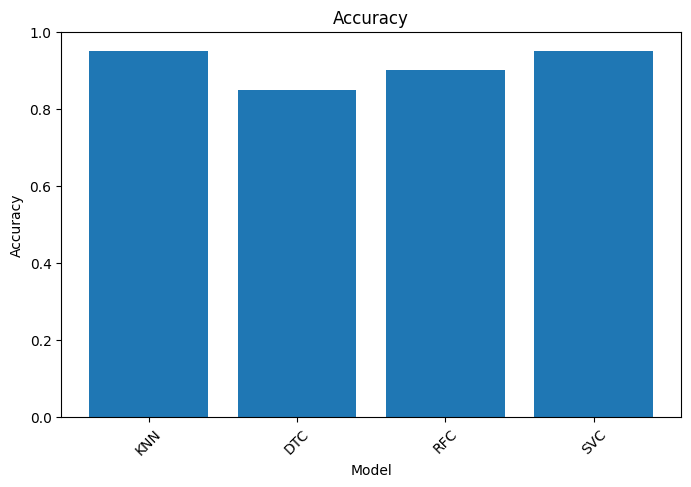

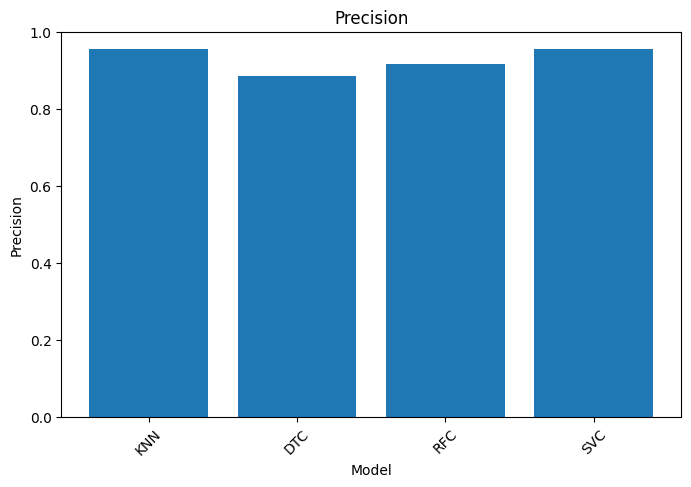

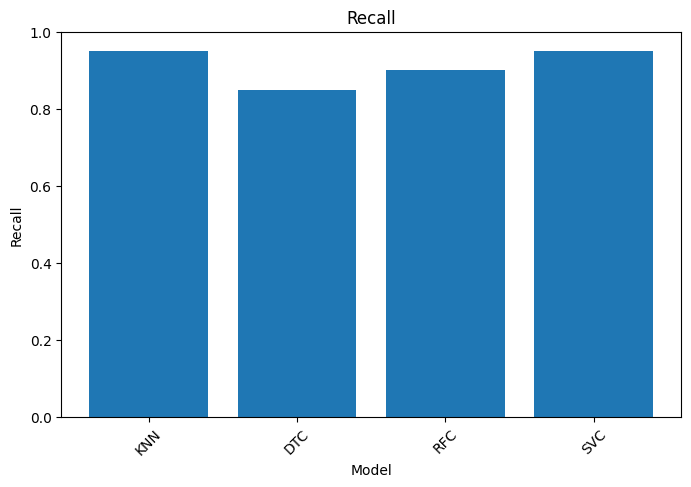

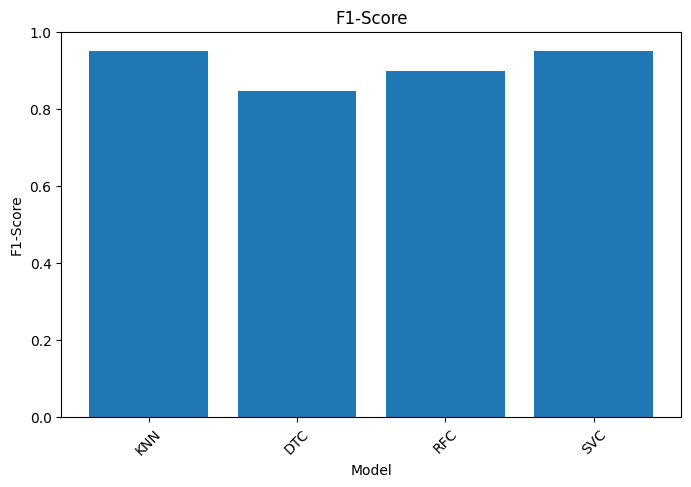

In [187]:
all_metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

for metric in all_metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(df_results.index, df_results[metric])
    plt.title(metric)
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.show()

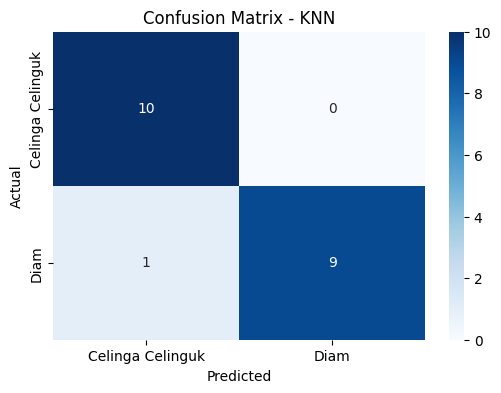

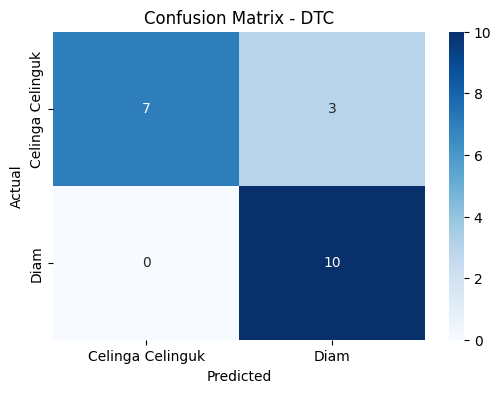

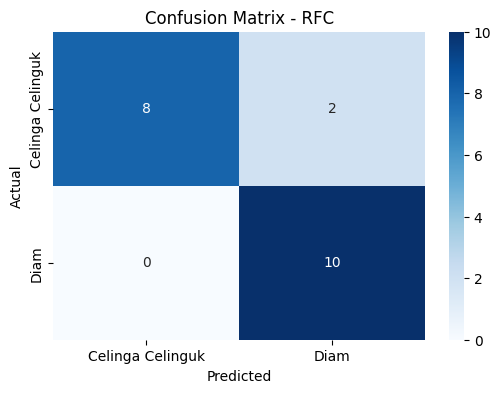

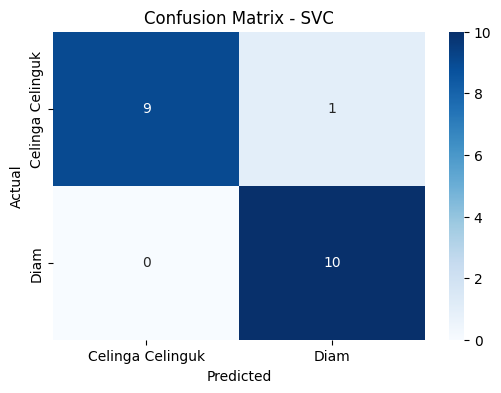

In [188]:

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)

    y_pred_labels = [class_mapping[i] for i in y_pred]
    y_test_labels = [class_mapping[i] for i in y_test]

    cm = confusion_matrix(y_test_labels, y_pred_labels)
    
    plt.figure(figsize=(6,4))


    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues",
        xticklabels=list(class_mapping.values()),
        yticklabels=list(class_mapping.values())
    )


    plt.title(f"Confusion Matrix - {name.upper()}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## PERFORMANCE (BEST MODEL - SVC)

In [189]:
df_results.loc['SVC']

Accuracy     0.950000
Precision    0.954545
Recall       0.950000
F1-Score     0.949875
Name: SVC, dtype: float64

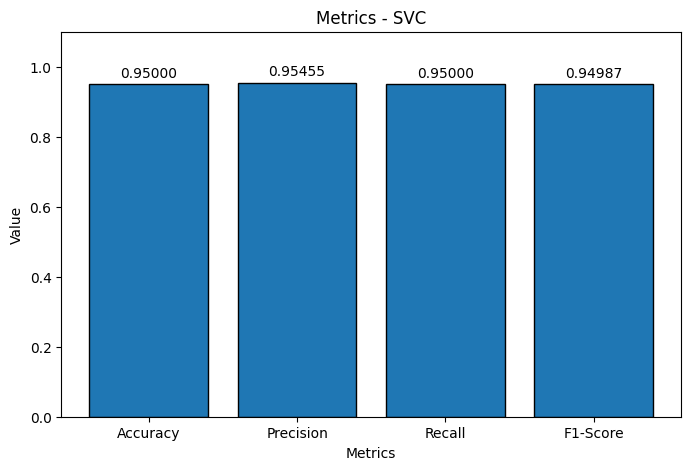

In [190]:
all_metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
svc_metrics = df_results.loc['SVC']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(svc_metrics.index, svc_metrics.values, edgecolor="black")
ax.set_title("Metrics - SVC")
ax.set_ylabel("Value")
ax.set_xlabel("Metrics")
plt.ylim(0, 1.1)

ax.bar_label(bars, labels=[f"{val:.5f}" for val in svc_metrics.values], padding=3)
plt.show()

# MODEL PREPARATION & TRAINING (TENSORFLOW)

In [191]:
MODEL_INPUT_SHAPE = (X_train.shape[1],)
MODEL_TOTAL_OUTPUT = len(np.unique(y_train))
BEST_MODEL_PATH = "Model/model_2class_nn.h5"

In [192]:
print(MODEL_INPUT_SHAPE, MODEL_TOTAL_OUTPUT)

(660,) 2


In [193]:
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",                      
)

earlystop_cb = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
)

In [194]:
nn_model = models.Sequential([
    layers.Dense(16, input_shape=MODEL_INPUT_SHAPE, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(np.unique(y_train)), activation='softmax'),
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

d:\Project Coding\Research\suspicious_detection_cctv\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [195]:
history = nn_model.fit(
    X_train, y_train, 
    epochs=30,
    validation_split=0.2,
    # callbacks=[checkpoint_cb, earlystop_cb])
    callbacks=[checkpoint_cb])

Epoch 1/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.5000 - loss: 0.8668

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.4375 - loss: 0.8403 - val_accuracy: 0.3125 - val_loss: 0.7471
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5729 - loss: 0.6688 - val_accuracy: 0.3125 - val_loss: 0.8231
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5000 - loss: 0.7011 - val_accuracy: 0.3125 - val_loss: 0.7862
Epoch 4/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4062 - loss: 0.7288

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4896 - loss: 0.7090 - val_accuracy: 0.4375 - val_loss: 0.7658
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6042 - loss: 0.6765 - val_accuracy: 0.3125 - val_loss: 0.7904
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6979 - loss: 0.6333 - val_accuracy: 0.3750 - val_loss: 0.8102
Epoch 7/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6562 - loss: 0.6766

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7188 - loss: 0.6456 - val_accuracy: 0.5000 - val_loss: 0.8071
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6667 - loss: 0.6082 - val_accuracy: 0.5000 - val_loss: 0.8143
Epoch 9/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6562 - loss: 0.6526

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6979 - loss: 0.6380 - val_accuracy: 0.5625 - val_loss: 0.8132
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6250 - loss: 0.6314 - val_accuracy: 0.5625 - val_loss: 0.7705
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6146 - loss: 0.6234 - val_accuracy: 0.5625 - val_loss: 0.7899
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7604 - loss: 0.6001 - val_accuracy: 0.5625 - val_loss: 0.8278
Epoch 13/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6250 - loss: 0.6507

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6667 - loss: 0.6220 - val_accuracy: 0.6250 - val_loss: 0.8578
Epoch 14/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7188 - loss: 0.5571 - val_accuracy: 0.5625 - val_loss: 0.8633
Epoch 15/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6354 - loss: 0.6043 - val_accuracy: 0.5625 - val_loss: 0.8275
Epoch 16/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6667 - loss: 0.5586 - val_accuracy: 0.5625 - val_loss: 0.8422
Epoch 17/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8125 - loss: 0.5248 - val_accuracy: 0.5000 - val_loss: 0.8880
Epoch 18/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7292 - loss: 0.5219 - val_accuracy: 0.5000 - val_loss: 0.8913
Epoch 19/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8750 - loss: 0.4416

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8125 - loss: 0.4814 - val_accuracy: 0.6875 - val_loss: 0.8393
Epoch 20/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8229 - loss: 0.5279 - val_accuracy: 0.6250 - val_loss: 0.7831
Epoch 21/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7917 - loss: 0.4629 - val_accuracy: 0.6875 - val_loss: 0.7534
Epoch 22/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8229 - loss: 0.4611 - val_accuracy: 0.6875 - val_loss: 0.7475
Epoch 23/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9062 - loss: 0.3872

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8542 - loss: 0.4233 - val_accuracy: 0.7500 - val_loss: 0.7474
Epoch 24/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8958 - loss: 0.4033 - val_accuracy: 0.7500 - val_loss: 0.7328
Epoch 25/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9271 - loss: 0.3637 - val_accuracy: 0.7500 - val_loss: 0.6935
Epoch 26/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8750 - loss: 0.4149 - val_accuracy: 0.7500 - val_loss: 0.6965
Epoch 27/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8958 - loss: 0.3888 - val_accuracy: 0.6875 - val_loss: 0.7361
Epoch 28/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9062 - loss: 0.3511 - val_accuracy: 0.6250 - val_loss: 0.7394
Epoch 29/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8750 - loss: 0.3341 - val_accuracy: 0.6875 - val_loss: 0.7057
Epoch 30/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9271 - loss: 0.2891 - val_accuracy: 0.7500 - val_loss: 0.6905


## MODEL PERFORMANCE

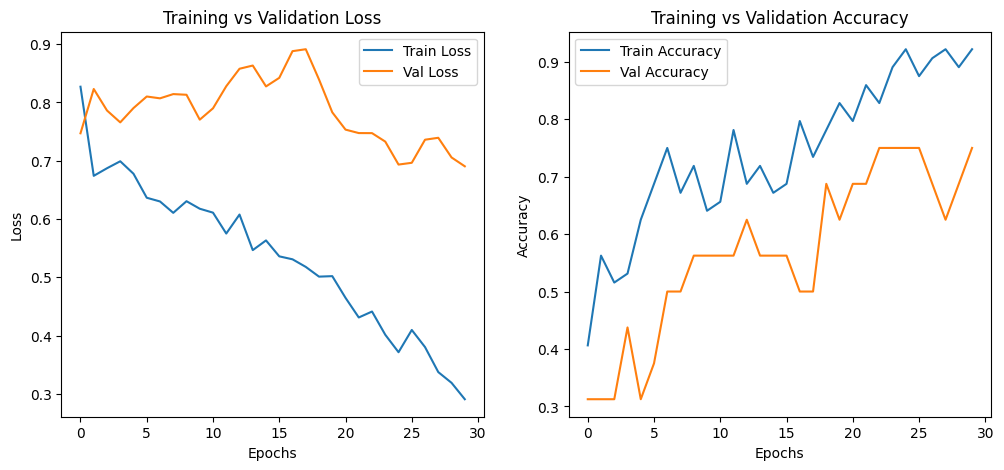

In [196]:
hist = history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['accuracy'], label='Train Accuracy')
plt.plot(hist['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

In [197]:
class_mapping

{0: 'Celinga Celinguk', 1: 'Diam'}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
['Celinga Celinguk', 'Diam', 'Diam', 'Celinga Celinguk', 'Diam']
['Diam', 'Diam', 'Celinga Celinguk', 'Diam', 'Celinga Celinguk']


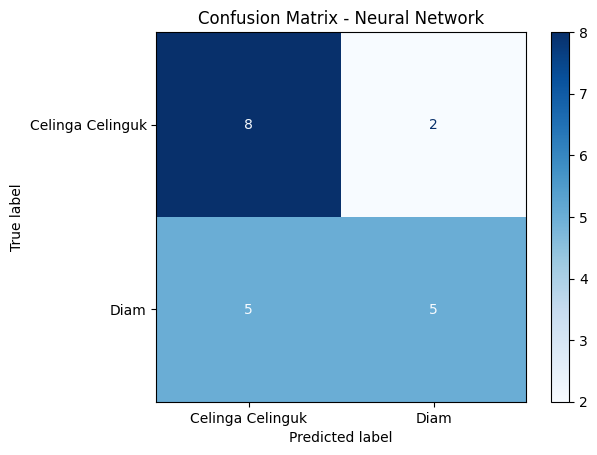

In [198]:
y_pred_probs = nn_model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

y_pred = [class_mapping[i] for i in y_pred]
y_test_labels = [class_mapping[i] for i in y_test]

print(y_pred[:5])
print(y_test_labels[:5])

cm = confusion_matrix(y_test_labels, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(class_mapping.values()))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Neural Network")
plt.show()